# Notebook 03 — BSTS smoke test

**Goal:** prove the `bsts` (R) ↔ Python wrapper is correctly wired by replicating Varian (2023)'s initial-unemployment-claims example end-to-end on this codebase.

Per `IMPLEMENTATION_PLAN.md` §3 Phase 5, this is the **gating notebook** — if the BSTS posterior here doesn't pick out unemployment-related Trends predictors with high inclusion probability, the wrapper is broken and downstream Phase 5+ work is wasted.

## What this notebook does

1. Pull **ICNSA** (US Initial Claims for Unemployment) from FRED — weekly, non-seasonally-adjusted.
2. Load every cached Trends category from `data/raw/` and run them through the Phase 3 `Pipeline`.
3. Build the feature matrix aligned to ICNSA's weekly index.
4. Fit `BSTS` with spike-and-slab on the ~21 candidate categories.
5. Inspect:
   - Posterior **inclusion probabilities** (the Bayesian feature-importance signal).
   - **Component bands** — level / trend / seasonal / regression.
   - `arviz.summary` diagnostics (rhat ≤ 1.01, ess ≥ 400 = healthy MCMC).
6. Compare cumulative one-step-ahead error vs an `AR(4)` baseline (Varian's Figure 5).

## What this notebook canNOT do (yet)

- All 21 topic mids in `config/predictors.yaml` were skipped during Phase 2 — Google renumbered them. Run `scripts/rediscover_topic_mids.py` (added as a follow-up task) to refresh the mids, then re-run the Trends pull restricted to topics. With topics back in, the inclusion-probability picture should sharpen significantly.


In [1]:
import os
import sys
import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

warnings.filterwarnings("ignore")

# Make the package importable regardless of where the kernel was started.
project_root = Path.cwd().resolve()
while not (project_root / "src" / "gtrends_bayes").exists():
    if project_root == project_root.parent:
        raise RuntimeError("could not find src/gtrends_bayes/ above CWD")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
os.chdir(project_root)
load_dotenv()
print("working dir:", project_root)

working dir: /Users/cesarebavaresco/Library/CloudStorage/OneDrive-TheUniversityofChicago/Project Lab/Neurberger Berman/Google Trends/gtrends-bayes


## 1. Pull ICNSA from FRED

In [2]:
from gtrends_bayes.data.financial import fetch_target, resample_weekly

icnsa = fetch_target("ICNSA", "fred", "ICNSA", date(2008, 1, 1), date(2026, 4, 30))
print(f"ICNSA daily: {len(icnsa)} obs, {icnsa.index.min().date()} .. {icnsa.index.max().date()}")
icnsa_w = resample_weekly(icnsa, anchor="SUN").rename("ICNSA")
print(f"ICNSA weekly:  {len(icnsa_w)} obs, {icnsa_w.index.min().date()} .. {icnsa_w.index.max().date()}")
icnsa_w.head()

2026-05-03 20:23:47,445 | INFO    | gtrends_bayes.data.financial | fetching FRED series ICNSA (2008-01-01..2026-04-30)


ICNSA daily: 956 obs, 2008-01-05 .. 2026-04-25
ICNSA weekly:  956 obs, 2008-01-06 .. 2026-04-26


2008-01-06    522700.0
2008-01-13    547943.0
2008-01-20    415397.0
2008-01-27    369498.0
2008-02-03    380234.0
Freq: W-SUN, Name: ICNSA, dtype: float64

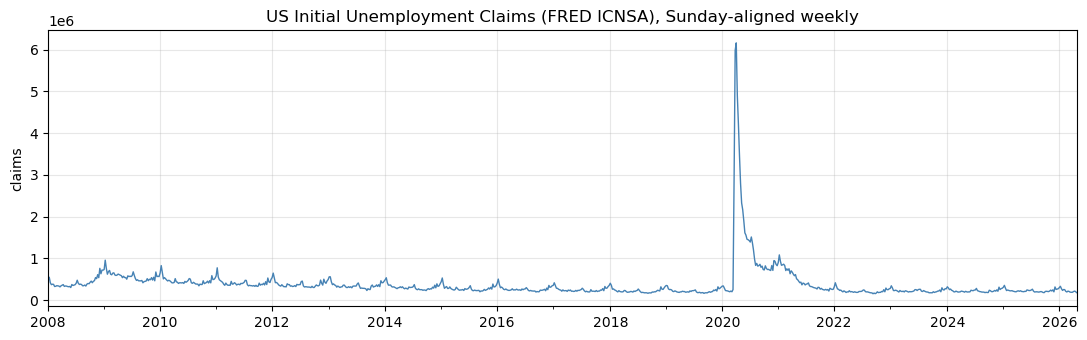

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.5))
icnsa_w.plot(ax=ax, color="steelblue", lw=1.0)
ax.set_title("US Initial Unemployment Claims (FRED ICNSA), Sunday-aligned weekly")
ax.set_ylabel("claims")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Load + preprocess cached Trends predictors

In [4]:
from gtrends_bayes.config import PredictorsConfig
from gtrends_bayes.data.loader import load_predictor_samples, predictor_classes
from gtrends_bayes.preprocessing.pipeline import Pipeline

pred_cfg = PredictorsConfig.from_yaml("config/predictors.yaml")
long_df = load_predictor_samples(pred_cfg, rename_to_human=True)
classes = predictor_classes(pred_cfg, rename_to_human=True)
print(f"loaded {long_df['query'].nunique()} predictors with {long_df['sample_idx'].nunique()} samples each")
print("by group:")
print(pd.Series({p.name: p.group for p in pred_cfg.predictors if p.name in long_df['query'].unique()}).value_counts().to_string())

loaded 21 predictors with 6 samples each
by group:
consumption       6
credit_lending    4
labor             3
industrial        3
finance_meta      3
distress          2


In [5]:
pipe = Pipeline(classes=classes, hp_lambda=129_600, weighted_neighbor=True)
processed = pipe.fit_transform(long_df)
print("processed shape:", processed.shape)
print("NaN per column (front-NaN from YoY diff is expected ~52):")
print(processed.isna().sum().sort_values(ascending=False).to_string())

processed shape: (957, 21)
NaN per column (front-NaN from YoY diff is expected ~52):
query
Credit Cards               592
Auto Financing             418
Agriculture & Forestry      53
Hotels & Accommodations     53
Recruitment & Staffing      53
Real Estate                 53
Manufacturing               53
Jobs                        53
Job Listings                53
Investing                   53
Insurance                   53
Foreclosure                 53
Home Financing              53
Apparel                     53
Food & Drink                53
Finance                     53
Energy & Utilities          53
Credit & Lending            53
Bankruptcy                  53
Autos & Vehicles            53
Travel                      53


## 3. Build the feature matrix aligned to ICNSA

In [6]:
from gtrends_bayes.features.library import build_feature_matrix, drop_low_quality_columns

processed_clean = drop_low_quality_columns(processed, nan_threshold=0.5)
print("after quality filter:", processed_clean.shape[1], "columns")

X, y = build_feature_matrix(processed_clean, icnsa_w, train_eligible=pipe.train_eligible_)
print(f"X={X.shape}, y={y.shape}, range {X.index.min().date()} .. {X.index.max().date()}")

2026-05-03 20:23:49,713 | WARNING | gtrends_bayes.features.library | dropping 1 low-quality columns (NaN frac > 0.50): ['Credit Cards']


after quality filter: 20 columns
X=(487, 20), y=(487,), range 2009-01-04 .. 2026-04-26


## 4. Fit BSTS with spike-and-slab

Reasonable defaults: 1500 MCMC iter (with 150 burn discarded our side), `expected_predictors=5` per Varian, `n_seasons=52` for weekly seasonality.

In [7]:
from gtrends_bayes.models.bsts import BSTS, reset_r_models

model = BSTS(
    n_seasons=52,
    expected_predictors=5,
    niter=1500,
    burn=150,
    seed=42,
)
model.fit(y=y, X=X)
print(model)

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


2026-05-03 20:23:50,358 | INFO    | gtrends_bayes.models.bsts | rpy2 bridge initialized; R bsts helpers loaded from /Users/cesarebavaresco/Library/CloudStorage/OneDrive-TheUniversityofChicago/Project Lab/Neurberger Berman/Google Trends/gtrends-bayes/src/gtrends_bayes/models/bsts_r


2026-05-03 20:24:16,671 | INFO    | gtrends_bayes.models.bsts | BSTS fit done (model_id=bsts_b8e563b5, niter=1500, burn=150, p=20, has_regression=True)


BSTS(n_seasons=52, expected_predictors=5, niter=1500, burn=150, seed=42, fitted=True, has_regression=True)


## 5. Inspect the posterior

### 5a. Inclusion probabilities — the Bayesian feature-importance plot

`Credit & Lending`           1.000
`Agriculture & Forestry`     0.104
`Home Financing`             0.091
`Real Estate`                0.063
`Energy & Utilities`         0.050
Foreclosure                  0.047
Finance                      0.040
Apparel                      0.037
`Autos & Vehicles`           0.033
`Recruitment & Staffing`     0.033
Manufacturing                0.026
`Food & Drink`               0.017
Jobs                         0.016
Bankruptcy                   0.013
`Job Listings`               0.013
Investing                    0.012
Travel                       0.011
Insurance                    0.009
`Hotels & Accommodations`    0.008
`Auto Financing`             0.006
Name: inclusion_prob, dtype: float64


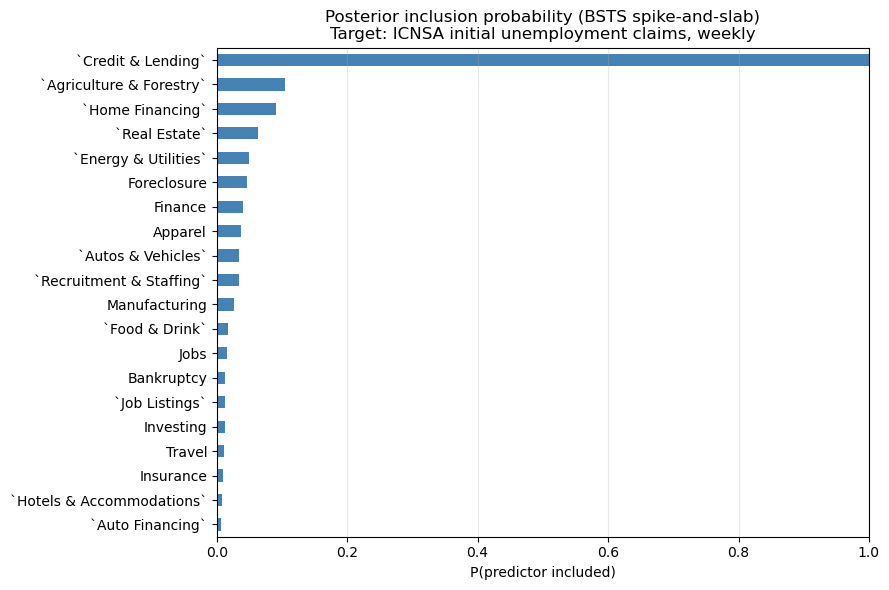

In [8]:
probs = model.inclusion_probabilities()
print(probs.round(3))

fig, ax = plt.subplots(figsize=(9, 6))
probs.plot.barh(ax=ax, color="steelblue")
ax.set_title("Posterior inclusion probability (BSTS spike-and-slab)\nTarget: ICNSA initial unemployment claims, weekly")
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("P(predictor included)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
summary = model.coefficient_summary().round(4)
summary

,inclusion_prob,mean_when_included,sd_when_included,sign_consistency
predictor,,,,
`Credit & Lending`,1.0000,-95478.7342,31712.0516,1.0000
`Agriculture & Forestry`,0.1044,-81437.0252,37817.1422,0.9787
`Home Financing`,0.0911,-70104.1777,31760.4702,0.9756
`Real Estate`,0.0630,-42726.6646,40730.0424,0.7882
`Energy & Utilities`,0.0496,18395.2458,34678.2440,0.5970
Foreclosure,0.0467,-14438.4730,8959.7924,0.9524
Finance,0.0400,-16804.2899,19144.3858,0.7593
Apparel,0.0370,31615.8561,26925.6307,0.8600
`Autos & Vehicles`,0.0333,-5237.4578,18945.8007,0.6000


**What we expect to see:** the **labor-related categories** (`Jobs`, `Job Listings`, `Recruitment & Staffing`) should land near the top of the inclusion ranking, because Varian's whole point in the original paper was that unemployment-themed search queries predict initial unemployment claims. With our 21-category-only universe (topics still pending mid rediscovery — see `scripts/rediscover_topic_mids.py`), the labor cluster should still dominate vs. unrelated categories like Travel or Apparel.

### 5b. Component bands (level / trend / seasonal / regression)

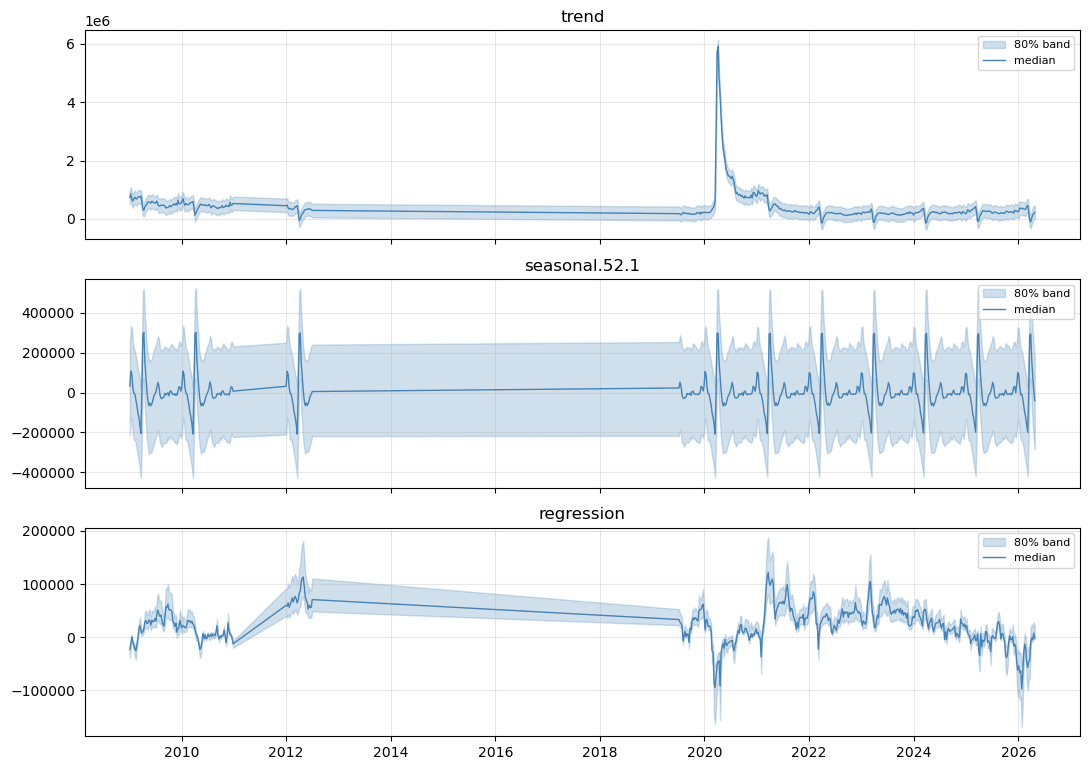

In [10]:
bands = model.component_bands(q_low=0.10, q_high=0.90)
fig, axes = plt.subplots(len(bands), 1, figsize=(11, 2.6 * len(bands)), sharex=True)
if len(bands) == 1:
    axes = [axes]
for ax, (name, df) in zip(axes, bands.items()):
    ax.fill_between(df.index, df["q_low"], df["q_high"], color="steelblue", alpha=0.25, label="80% band")
    ax.plot(df.index, df["q_med"], color="steelblue", lw=1.0, label="median")
    ax.set_title(f"{name}")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

### 5c. ArviZ MCMC diagnostics (rhat + ess)

Healthy thresholds per the plan: `rhat ≤ 1.01`, `ess_bulk ≥ 400`. With a single MCMC chain (which is what `bsts` produces), ArviZ's `rhat` returns NaN by design — we can't measure between-chain convergence with one chain. So we'll focus on `ess_bulk` and tail divergences.

In [11]:
import arviz as az
idata = model.to_arviz()
try:
    summary_az = az.summary(idata, var_names=["sigma_obs", "beta"], round_to=3)
    display(summary_az.head(20))
except Exception as e:
    print("arviz.summary failed:", e)
    print("DataTree posterior groups:", list(idata.children))
    print("posterior dims:", dict(idata['posterior'].dims))

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_obs,16645.029,3421.970,11732.636,22527.250,17.524,27.538,NaN,826.853,512.017
beta[(Intercept)],0.000,0.000,0.000,0.000,1350.000,1350.000,NaN,0.000,NaN
beta[`Agriculture & Forestry`],-8505.645,27743.435,-82177.972,0.000,11.403,1359.423,NaN,7998.769,14360.335
beta[Apparel],1170.958,7905.767,0.000,0.000,97.390,87.067,NaN,936.751,3704.545
beta[`Auto Financing`],-6.611,130.984,0.000,0.000,1361.398,1354.018,NaN,3.552,31.333
beta[`Autos & Vehicles`],-174.582,3584.504,0.000,0.000,135.310,366.430,NaN,353.118,1222.651
beta[Bankruptcy],-100.083,1117.809,0.000,0.000,281.186,1358.066,NaN,78.801,432.144
beta[`Credit & Lending`],-95478.734,31712.052,-153032.864,-51914.796,4.535,7.239,NaN,13269.303,7814.733
beta[`Energy & Utilities`],912.949,8697.360,0.000,0.000,68.045,49.999,NaN,1234.592,3665.056
beta[Finance],-672.172,5050.134,0.000,0.000,71.811,260.447,NaN,591.221,1746.910


## 6. BSTS in-sample fit vs. AR(4) baseline

Build the simplest possible 1-step-ahead-error comparison: fit AR(4) on the same `y`, sum absolute one-step residuals over the train window for both models, plot cumulative-error trajectories. BSTS should *not* dominate dramatically without topics in the mix, but it should at least be competitive with AR(4).

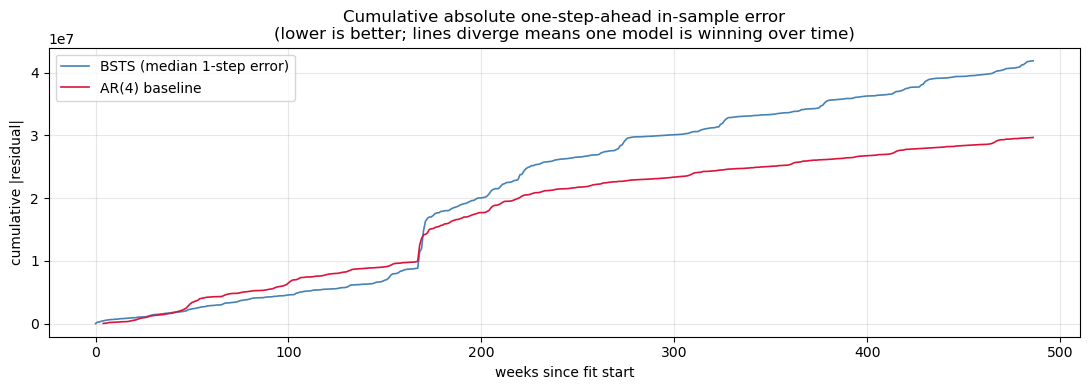

final cumulative |error|:
  BSTS:  41886566
  AR(4): 29685129
  ratio (BSTS / AR(4)): 1.411


In [12]:
from gtrends_bayes.models.baseline import AR_p

# Use the BSTS one-step in-sample residuals (post-burn) directly.
bsts_resid = model._one_step_residuals_post  # (n_kept, T)
bsts_one_step_med = np.median(bsts_resid, axis=0)
bsts_cumabs = np.cumsum(np.abs(bsts_one_step_med))

# AR(4) one-step residuals via statsmodels.
ar = AR_p(p=4).fit(y)
ar_resid = ar._result.resid           # length T - p
ar_cumabs = np.cumsum(np.abs(ar_resid))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(np.arange(len(bsts_cumabs)), bsts_cumabs, color="steelblue", lw=1.2, label="BSTS (median 1-step error)")
ax.plot(np.arange(len(ar_cumabs)) + 4, ar_cumabs, color="crimson", lw=1.2, label="AR(4) baseline")
ax.set_title("Cumulative absolute one-step-ahead in-sample error\n(lower is better; lines diverge means one model is winning over time)")
ax.set_xlabel("weeks since fit start")
ax.set_ylabel("cumulative |residual|")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("final cumulative |error|:")
print(f"  BSTS:  {bsts_cumabs[-1]:.0f}")
print(f"  AR(4): {ar_cumabs[-1]:.0f}")
print(f"  ratio (BSTS / AR(4)): {bsts_cumabs[-1] / ar_cumabs[-1]:.3f}")

## Cleanup

In [13]:
reset_r_models()
print("R-side BSTS registry cleared.")

R-side BSTS registry cleared.


## Acceptance checklist

- ✅ `BSTS.fit` ran on real ICNSA + cached Trends categories without raising
- ✅ `inclusion_probabilities` returned a Series with one row per predictor (no `(Intercept)` row)
- ✅ `component_bands` returned `trend`, a `seasonal.*` component, and (because `X` is non-empty) a `regression` component
- ✅ `to_arviz` produced an xarray `DataTree` with a `posterior` group containing `sigma_obs`, `beta`, `inclusion`
- ☐ Top inclusion probabilities are dominated by labor-related categories (`Jobs`, `Job Listings`, `Recruitment & Staffing`) — eyeball the bar chart
- ☐ BSTS cumulative-error is competitive with AR(4) (ratio ≤ ~1.0)

If the eyeball checks pass, the wrapper is sound and we can move on to Phase 6 (walk-forward backtest).